# RSI(2) Strategy Visualizer
# max stocks: 5
# Price Bracket: 90- 600
# max year: 3 (approx 750 trading days)
# DATA_DIR = 'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
# Seed : 5

In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading (3 Years)
all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(5) 
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 5: 
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        
        df = df.sort_values('Date').reset_index(drop=True)
        if len(df) < 800: # Need enough history for 3 years + 200 SMA buffer
            continue
            
        latest_price = df['Close'].iloc[-1]
        if not (90 <= latest_price <= 600):
            continue
            
        df['Symbol'] = symbol
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)
print(f"Loaded {len(data['Symbol'].unique())} stocks for 3 Years of RSI(2) analysis.")


Loaded 5 stocks for 3 Years of RSI(2) analysis.


In [3]:
# 3. Strategy Indicator Calculations & Backtest
def calc_rsi(series, period=2):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

enriched_data = []
trades = []
symbols = data['Symbol'].unique()

for symbol in symbols:
    df = data[data['Symbol'] == symbol].copy()
    
    # Simple Moving Averages
    df['SMA_200'] = df['Close'].rolling(200).mean()
    df['SMA_5'] = df['Close'].rolling(5).mean()
    
    # RSI(2)
    df['RSI_2'] = calc_rsi(df['Close'], 2)
    
    # Filter to last 750 days (approx 3 years of trading) for backtest period
    if len(df) > 750:
        df = df.tail(750).reset_index(drop=True)
    
    # The Setup Condition
    df['Setup'] = (df['Close'] > df['SMA_200']) & (df['RSI_2'] < 10)
    
    in_trade = False
    entry_price = 0
    entry_date = None
    days_held = 0
    
    for i, row in df.iterrows():
        if pd.isna(row['SMA_200']):
            continue
            
        # Manage Open Trades
        if in_trade:
            days_held += 1
            exit_triggered = False
            exit_reason = ""
            
            # Check Strategy Exits
            if row['Close'] > row['SMA_5']:
                exit_triggered = True
                exit_reason = "Close > 5 SMA"
            
            # Failsafe Stops
            if not exit_triggered:
                profit_pct = (row['Close'] - entry_price) / entry_price
                if profit_pct <= -0.08:
                    exit_triggered = True
                    exit_reason = "Hard Stop (-8%)"
            
            if exit_triggered:
                profit_pct = (row['Close'] - entry_price) / entry_price
                trades.append({
                    'Symbol': symbol,
                    'Entry_Date': entry_date,
                    'Exit_Date': row['Date'],
                    'Entry_Price': entry_price,
                    'Exit_Price': row['Close'],
                    'Profit_Pct': profit_pct * 100,
                    'Days_Held': days_held,
                    'Reason': exit_reason
                })
                in_trade = False
                days_held = 0
                
        # Look for Entries (Only if Macro Trend is UP)
        if not in_trade and row['Setup']:
            in_trade = True
            entry_price = row['Close']
            entry_date = row['Date']
            
    enriched_data.append(df)

data = pd.concat(enriched_data, ignore_index=True)
trades_df = pd.DataFrame(trades)

# Summary
if len(trades_df) > 0:
    total_trades = len(trades_df)
    winners = trades_df[trades_df['Profit_Pct'] > 0]
    losers = trades_df[trades_df['Profit_Pct'] <= 0]
    
    win_rate = len(winners) / total_trades * 100
    avg_win = winners['Profit_Pct'].mean() if len(winners) > 0 else 0
    avg_loss = losers['Profit_Pct'].mean() if len(losers) > 0 else 0
    avg_profit = trades_df['Profit_Pct'].mean()
    
    summary_html = f'''
    <h3>RSI(2) Strategy Summary (3 Years)</h3>
    <ul>
        <li><b>Total Trades:</b> {total_trades}</li>
        <li><b>Win Rate:</b> {win_rate:.2f}%</li>
        <li><b>Net Avg Profit:</b> {avg_profit:.2f}%</li>
        <li><b>Average Win:</b> +{avg_win:.2f}%</li>
        <li><b>Average Loss:</b> {avg_loss:.2f}%</li>
    </ul>
    '''
    
    display(HTML(summary_html))
    display(trades_df.head(15)) # Show top 15 trades
else:
    print("No trades triggered.")


,Symbol,Entry_Date,Exit_Date,Entry_Price,Exit_Price,Profit_Pct,Days_Held,Reason
0,SYNGENE,2023-07-19,2023-07-20,769.799988,781.650024,1.539366,1,Close > 5 SMA
1,SYNGENE,2023-07-24,2023-07-25,773.250000,776.750000,0.452635,1,Close > 5 SMA
2,SYNGENE,2023-08-03,2023-08-04,798.599976,810.849976,1.533934,1,Close > 5 SMA
3,SYNGENE,2023-08-09,2023-08-16,802.650024,805.299988,0.330152,4,Close > 5 SMA
4,SYNGENE,2023-08-18,2023-08-21,803.299988,810.799988,0.933649,1,Close > 5 SMA
5,SYNGENE,2023-08-24,2023-08-31,796.400024,774.049988,-2.806383,5,Close > 5 SMA
6,SYNGENE,2023-09-11,2023-09-25,838.450012,770.049988,-8.157913,9,Hard Stop (-8%)
7,SYNGENE,2023-09-25,2023-09-28,770.049988,777.950012,1.025911,3,Close > 5 SMA
8,SYNGENE,2023-10-05,2023-10-12,787.950012,796.250000,1.053365,5,Close > 5 SMA
9,SYNGENE,2023-10-16,2023-10-19,776.900024,713.099976,-8.212131,3,Hard Stop (-8%)


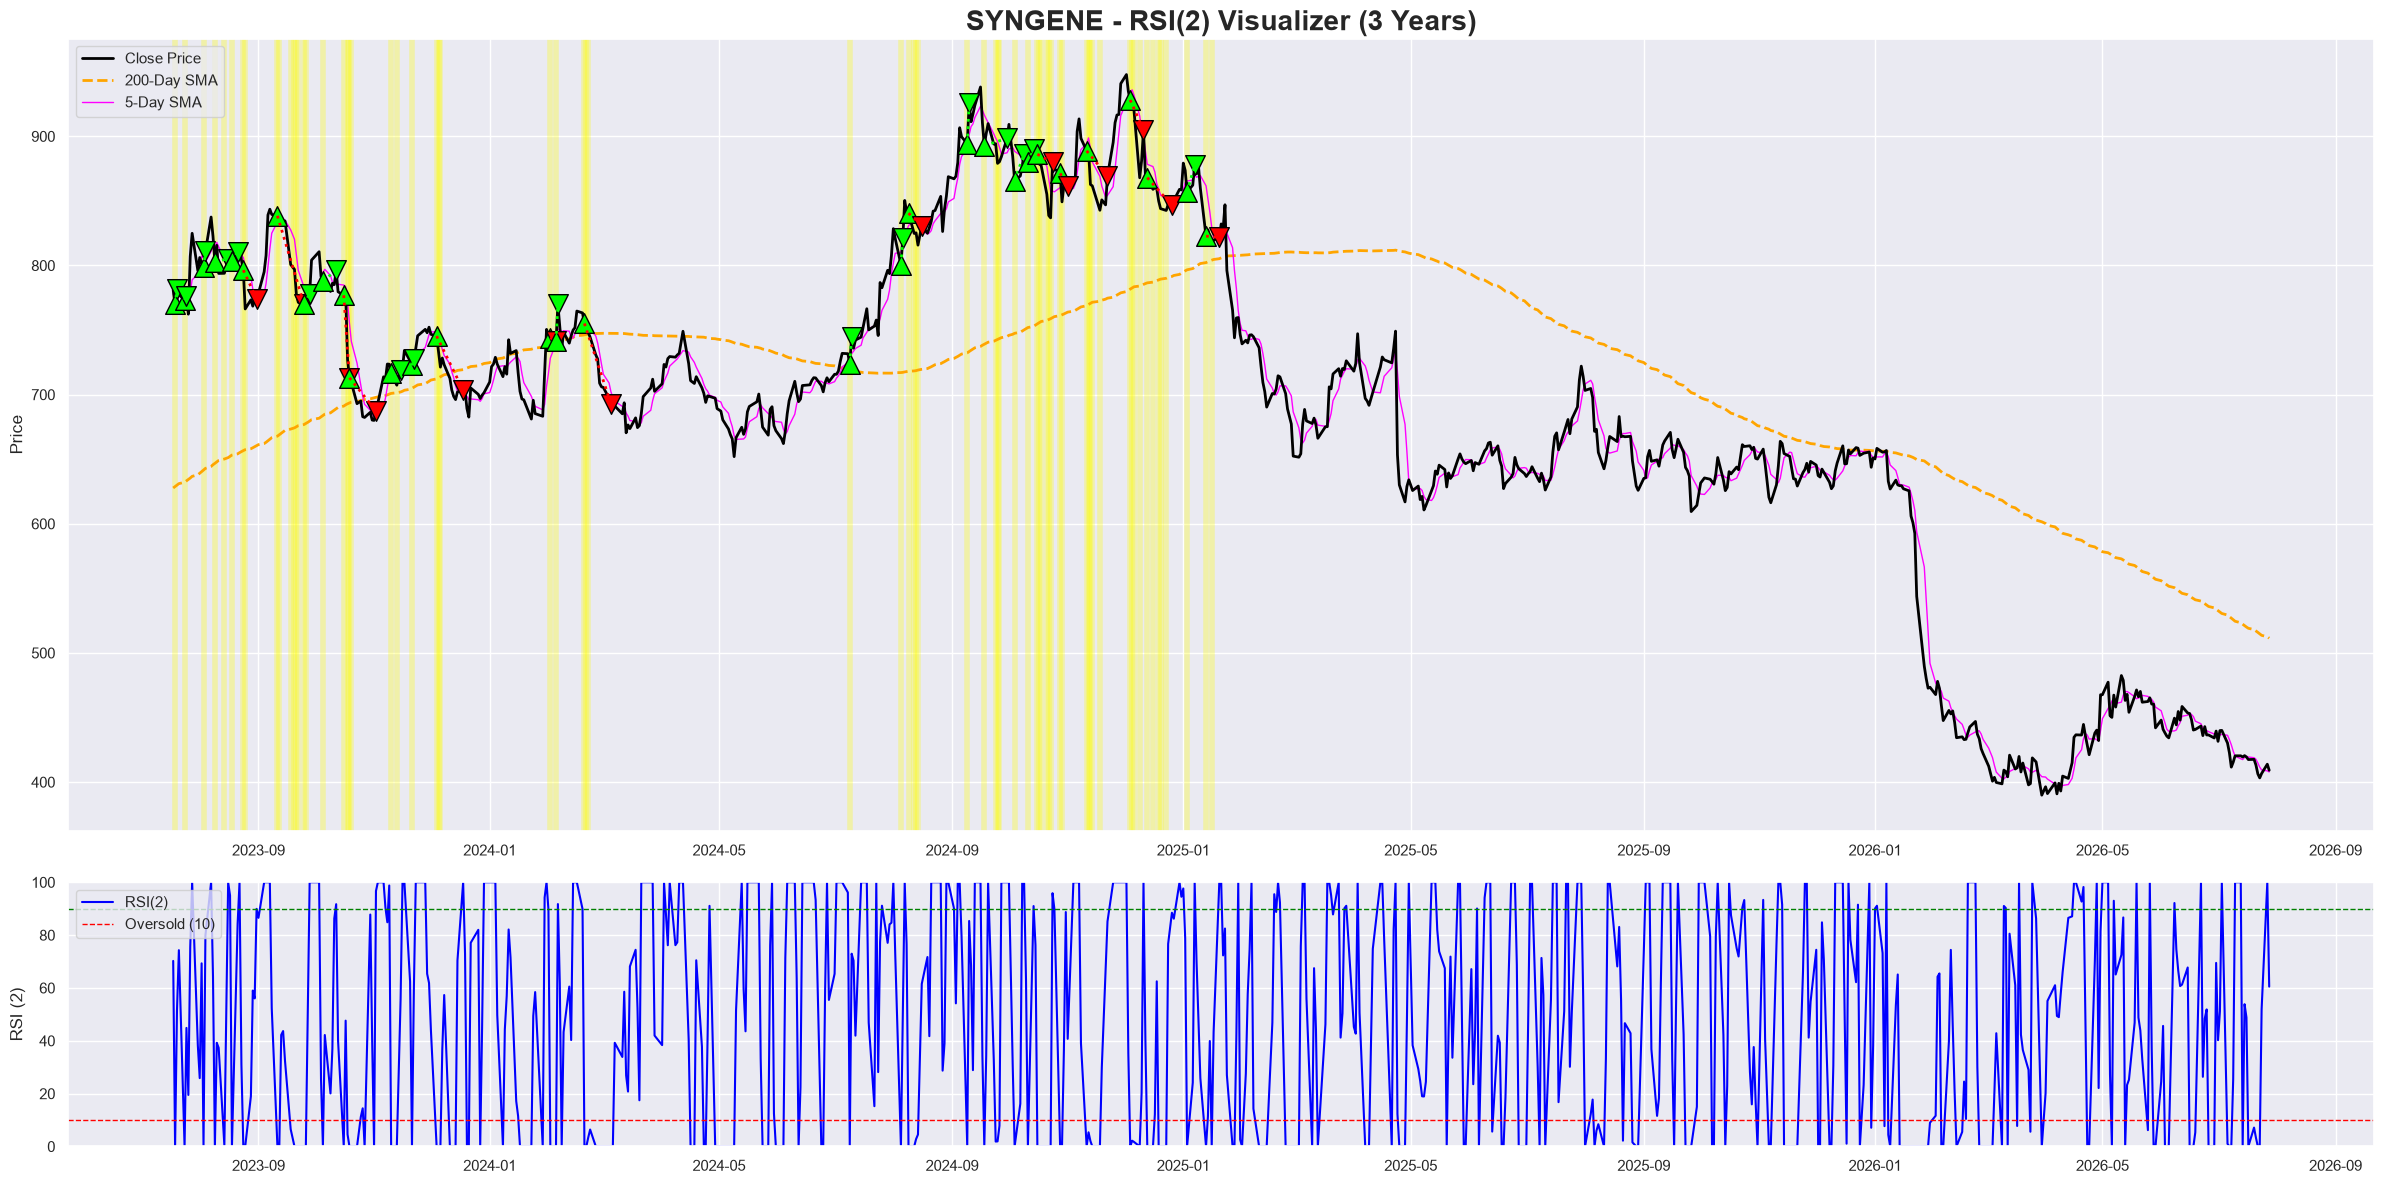

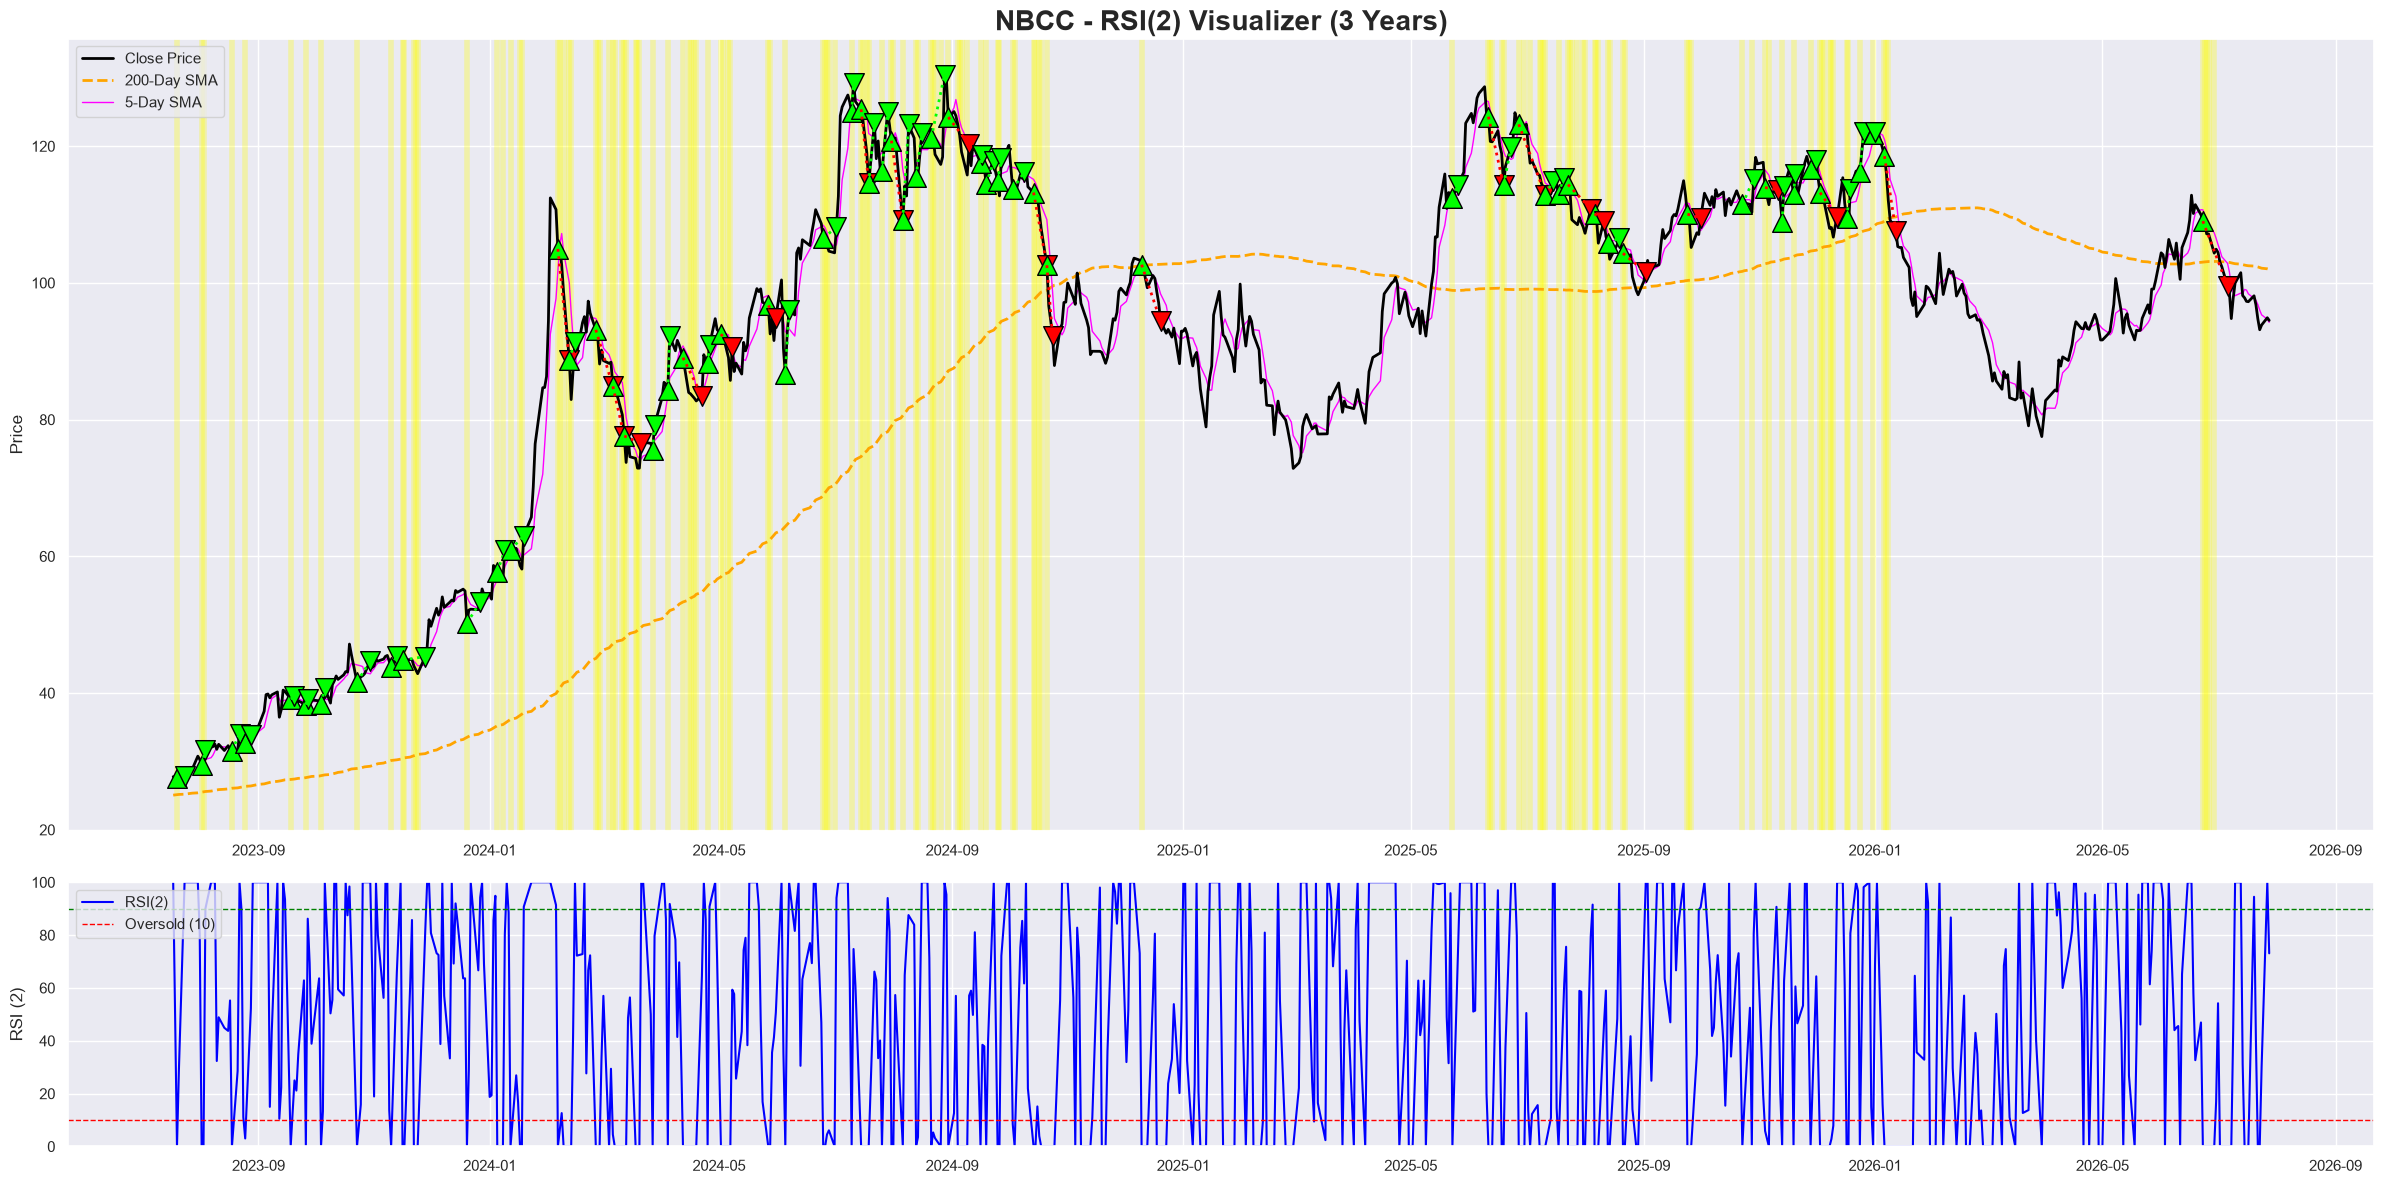

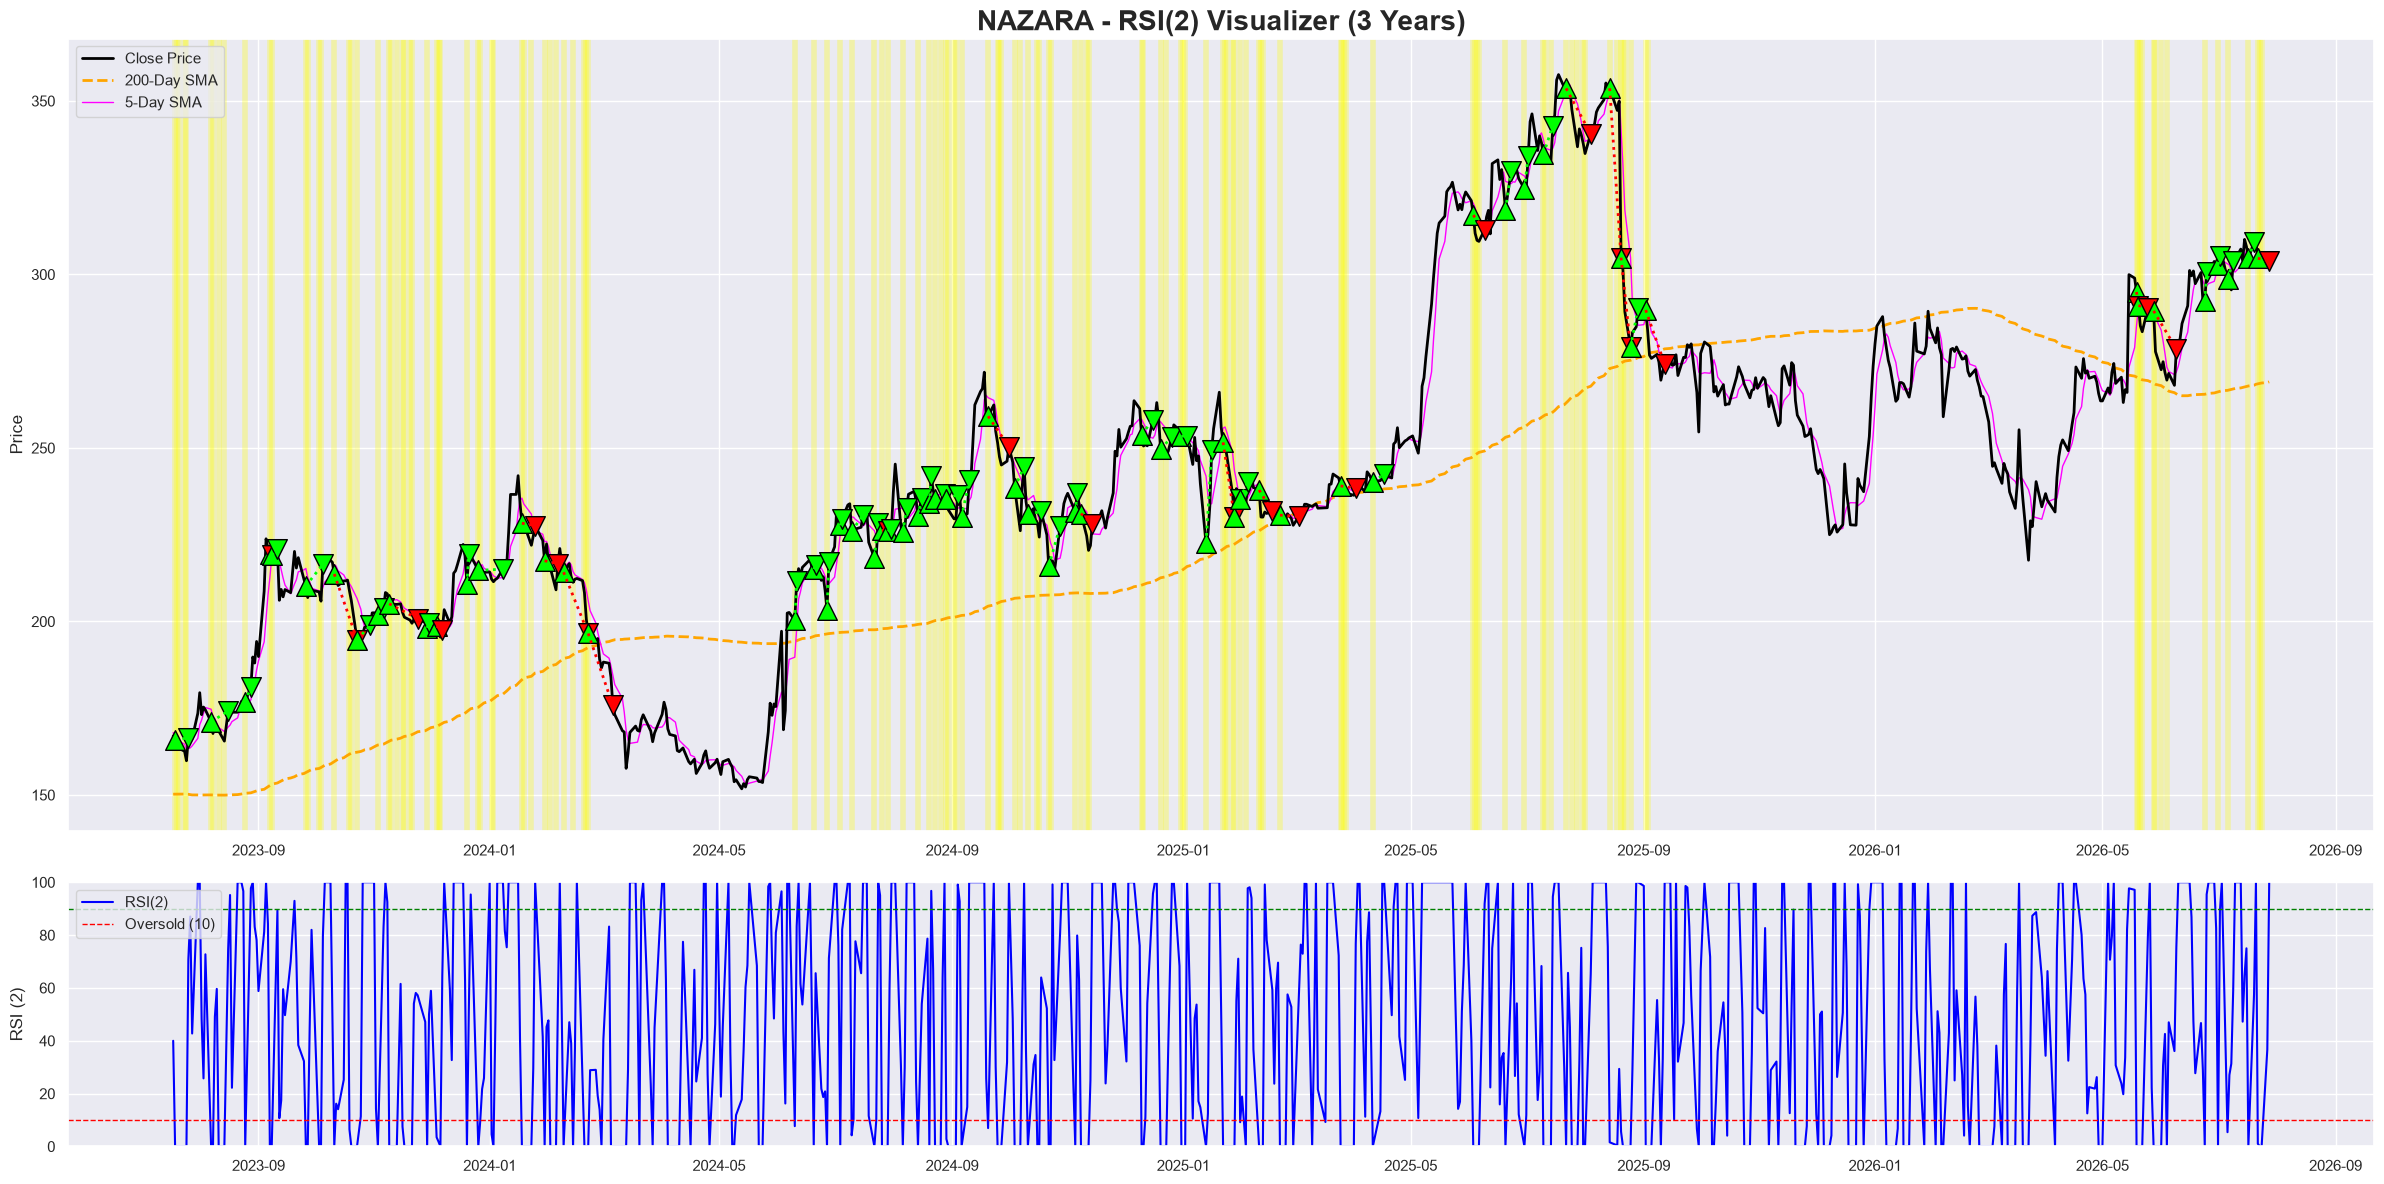

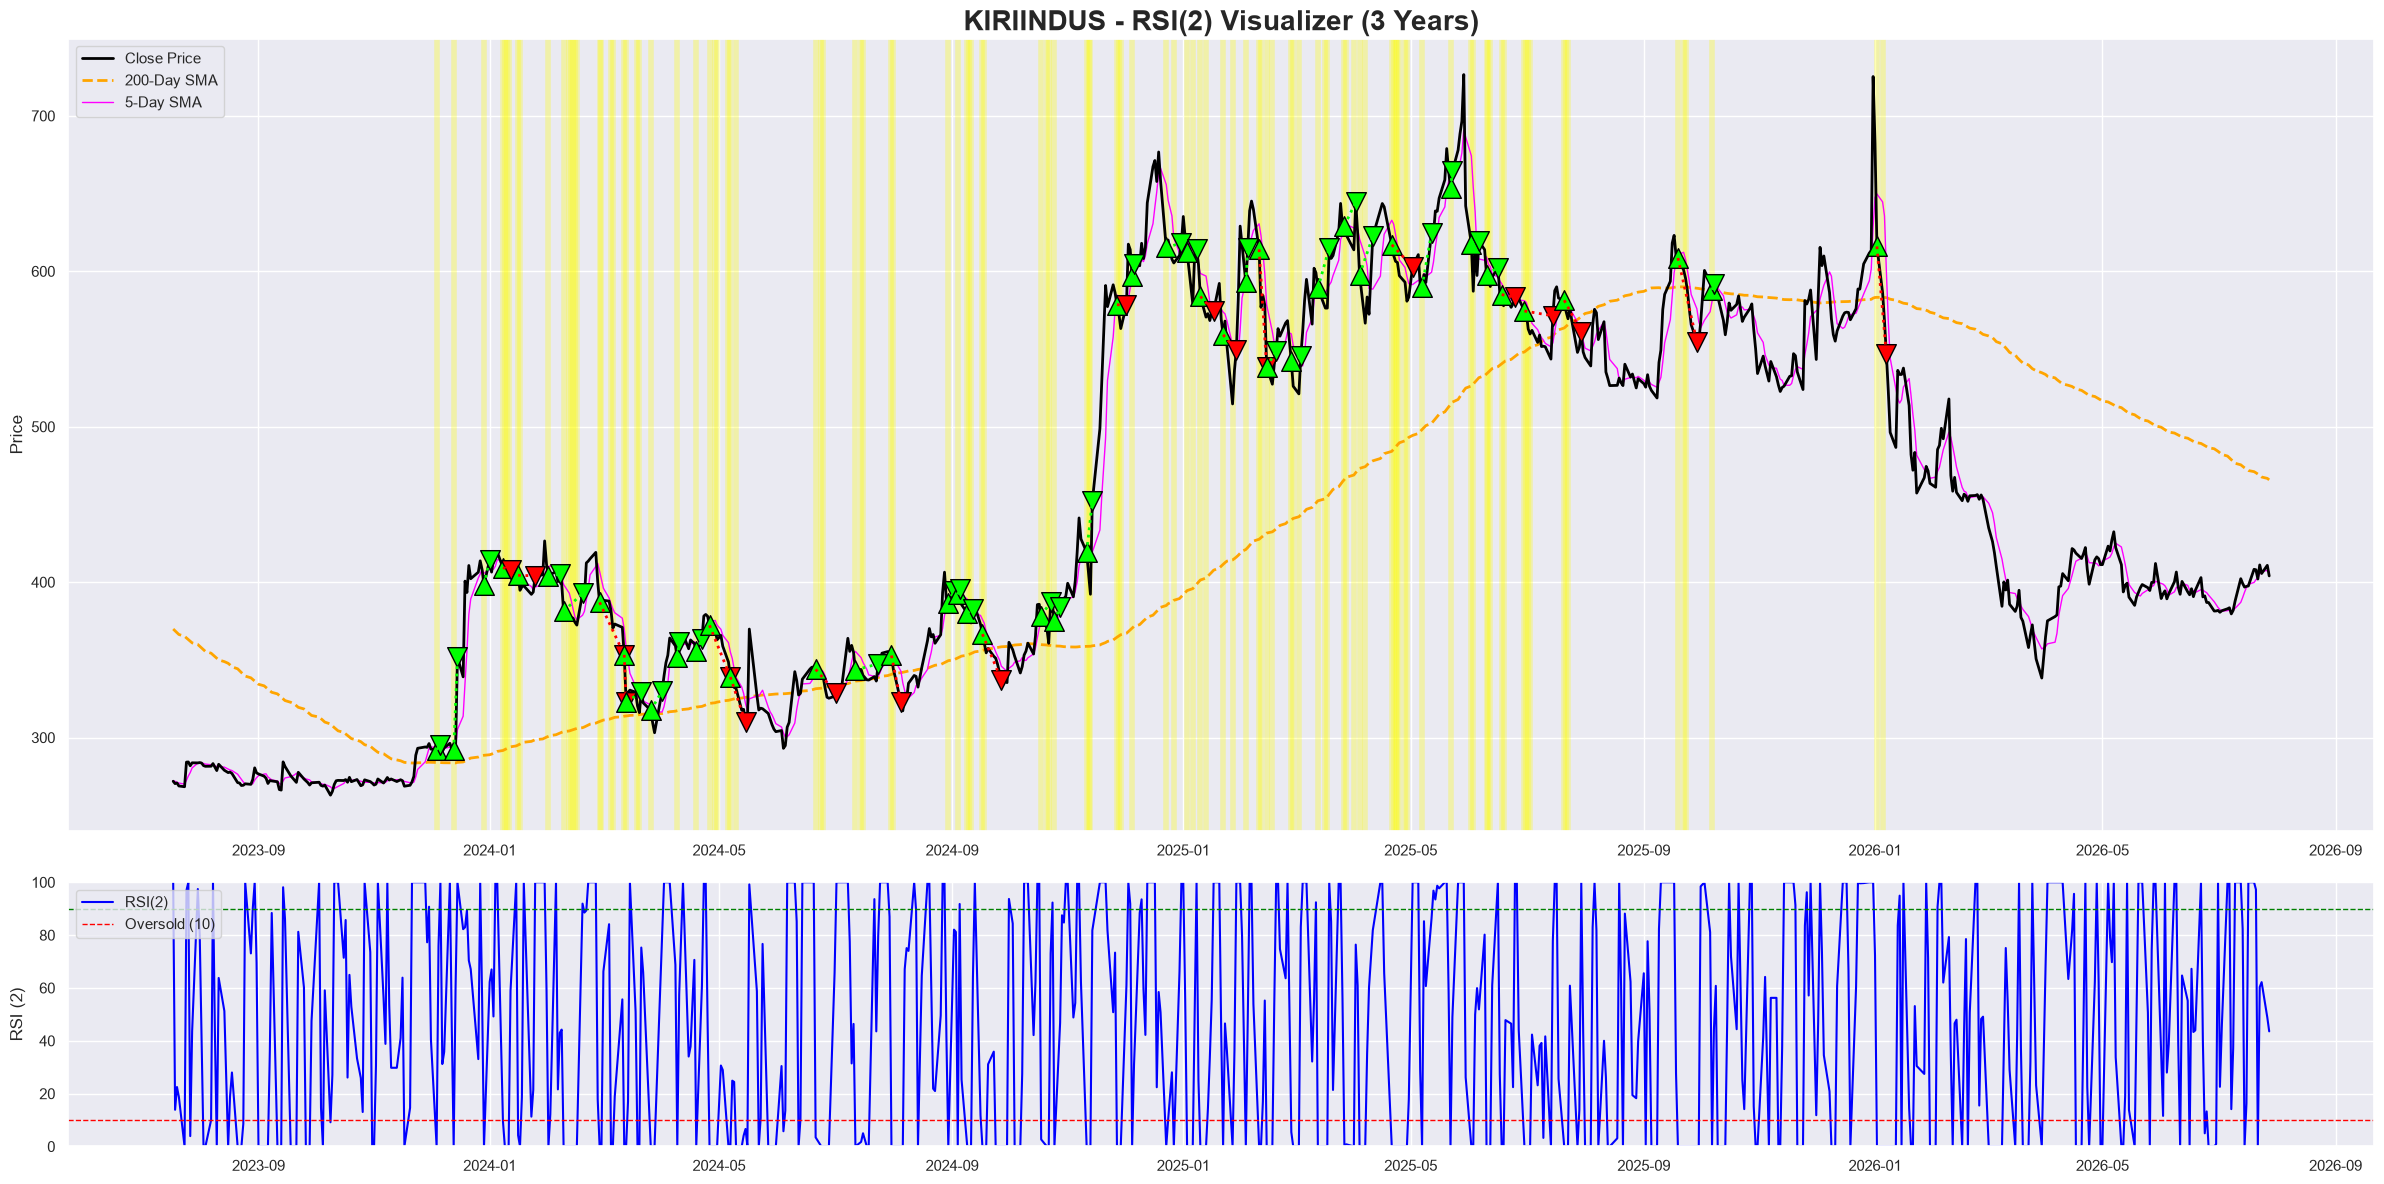

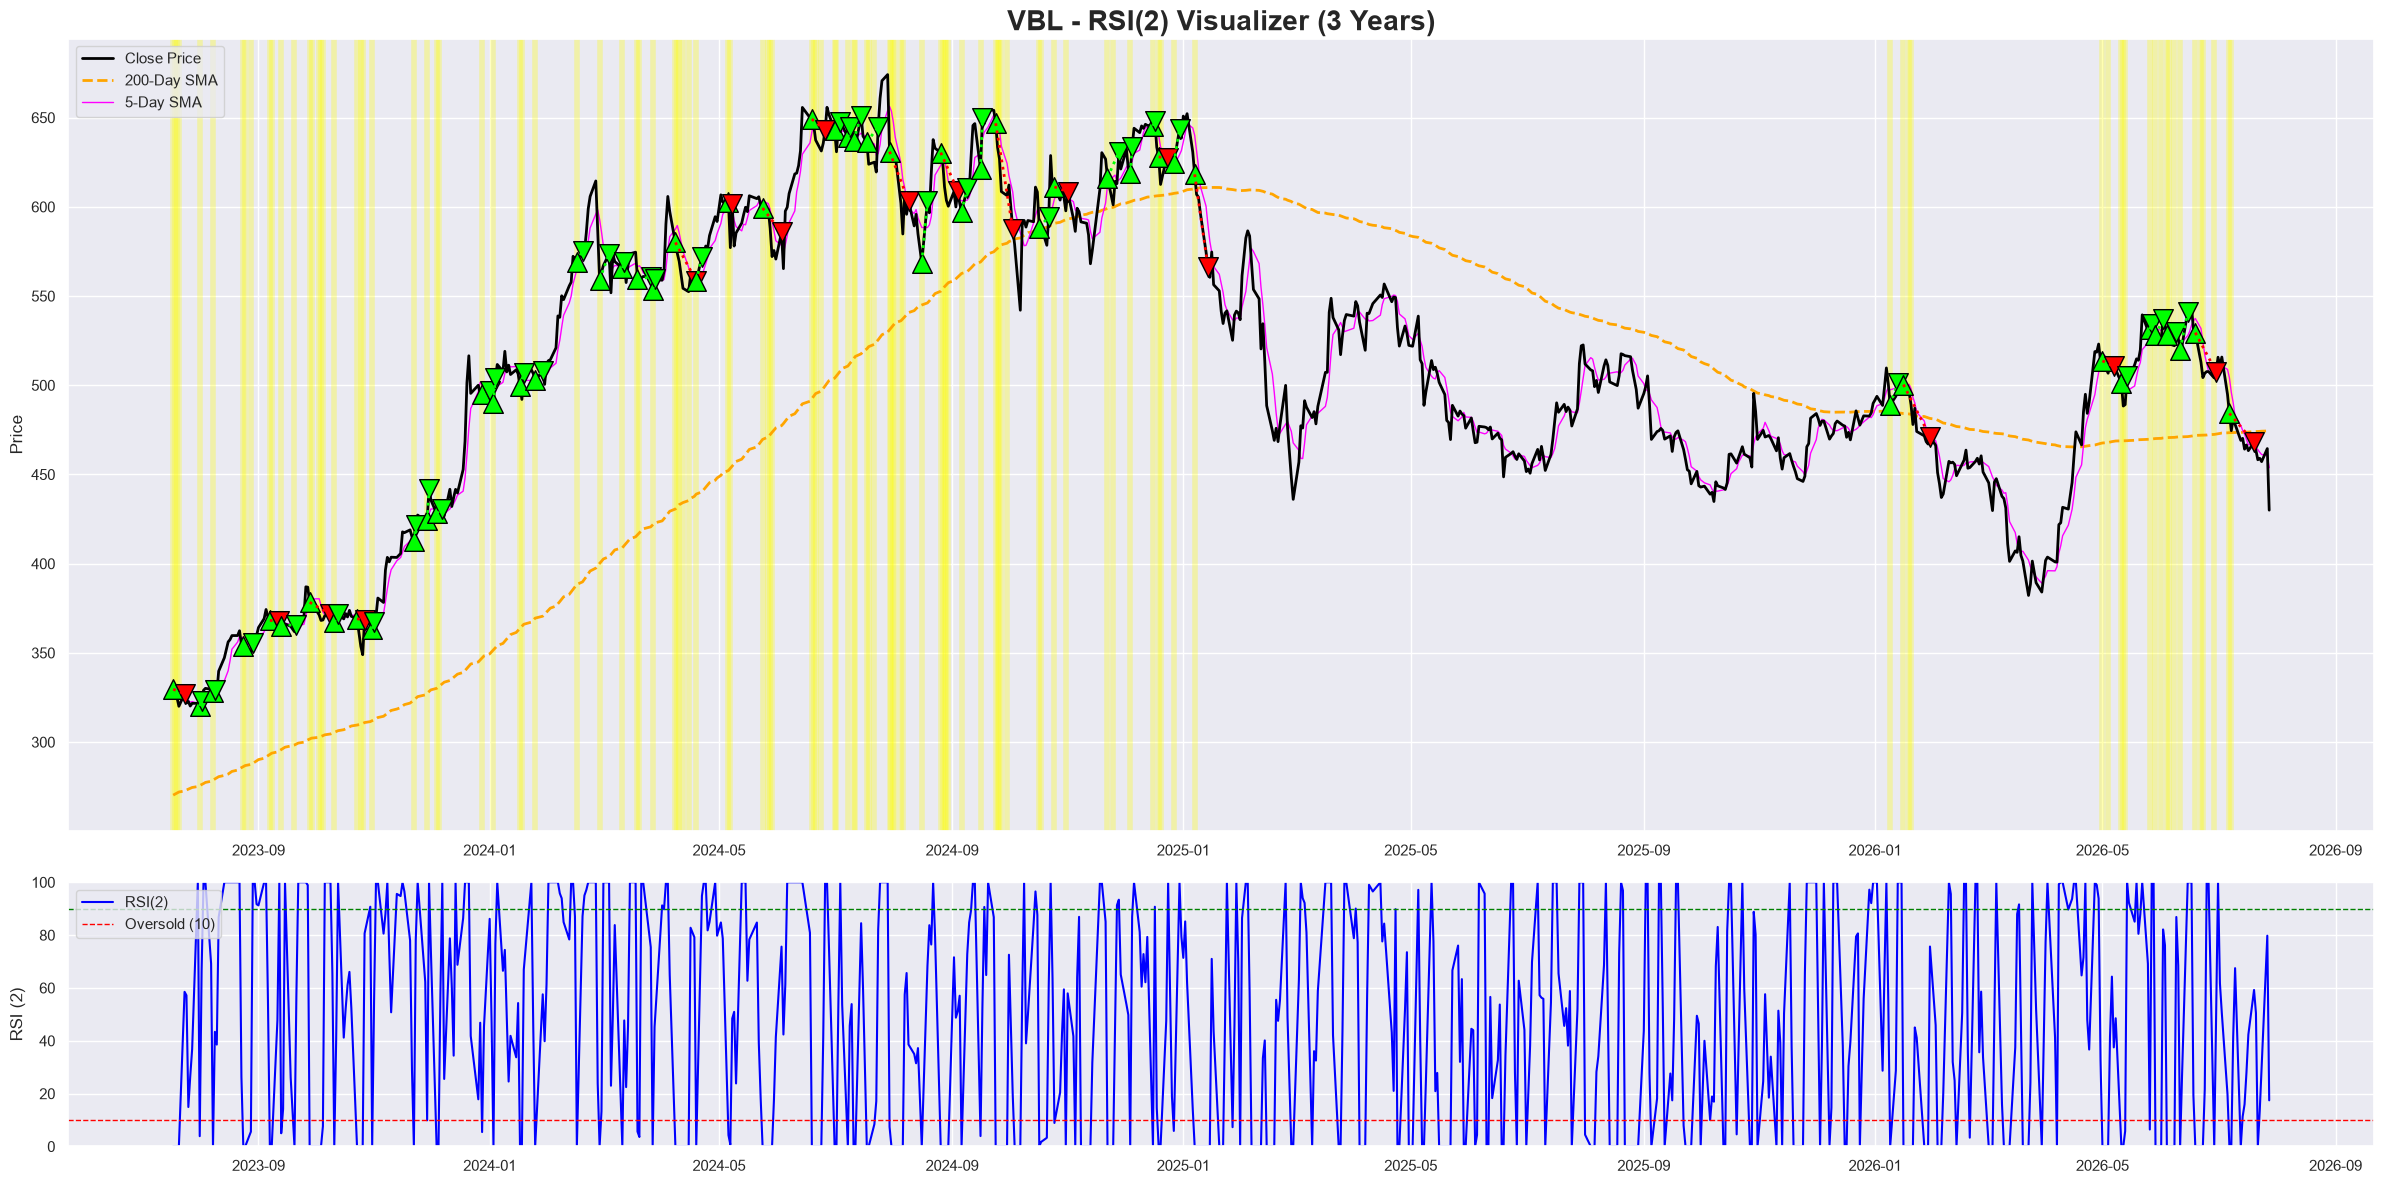

In [4]:
# 4. Visualizing the Trades & Setup Days
for symbol in symbols:
    df = data[data['Symbol'] == symbol].reset_index(drop=True)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 12), gridspec_kw={'height_ratios': [3, 1]})
    
    # Top Plot: Price and Setup Background
    ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=2, zorder=5)
    ax1.plot(df['Date'], df['SMA_200'], label='200-Day SMA', color='orange', linewidth=2, linestyle='--')
    ax1.plot(df['Date'], df['SMA_5'], label='5-Day SMA', color='magenta', linewidth=1)
    
    ax1.set_title(f"{symbol} - RSI(2) Visualizer (3 Years)", fontsize=20, fontweight='bold')
    ax1.set_ylabel('Price')
    ax1.legend(loc='upper left')
    
    # Highlight Setup Days (Yellow vertical bars)
    setup_dates = df[df['Setup']]['Date']
    for sd in setup_dates:
        ax1.axvline(x=sd, color='yellow', alpha=0.3, linewidth=4, zorder=1)
    
    # Bottom Plot: RSI(2)
    ax2.plot(df['Date'], df['RSI_2'], label='RSI(2)', color='blue', linewidth=1.5)
    ax2.axhline(10, color='red', linewidth=1, linestyle='--', label='Oversold (10)')
    ax2.axhline(90, color='green', linewidth=1, linestyle='--')
    ax2.set_ylabel('RSI (2)')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')
    
    # Plot Entries and Exits
    if len(trades_df) > 0:
        stock_trades = trades_df[trades_df['Symbol'] == symbol]
        for idx, trade in stock_trades.iterrows():
            ax1.scatter(trade['Entry_Date'], trade['Entry_Price'], color='lime', marker='^', s=200, zorder=6, edgecolors='black')
            exit_color = 'lime' if trade['Profit_Pct'] > 0 else 'red'
            ax1.scatter(trade['Exit_Date'], trade['Exit_Price'], color=exit_color, marker='v', s=200, zorder=6, edgecolors='black')
            ax1.plot([trade['Entry_Date'], trade['Exit_Date']], [trade['Entry_Price'], trade['Exit_Price']], color=exit_color, linestyle=':', linewidth=2, zorder=6)
    
    plt.tight_layout()
    plt.show()
